# Zero-Day Attack Classification — Bot-IoT

**Experiment:** Withhold one attack class entirely from training. Generate binary (normal/attack) rules using the RAG-LLM pipeline on the remaining data. Evaluate on the withheld class at test time to measure zero-day generalisation.

**Key metric:** Zero-Day Detection Rate (ZDR) = fraction of withheld-class entries flagged as 'attack'.

**Dataset notes:**
- Label column: `subcategory` (classes: UDP, TCP, Service_Scan, OS_Fingerprint, HTTP, Normal, Keylogging, Data_Exfiltration)
- Benign class: `Normal` (only 370 rows — very small; training pool is 1:1 balanced to this count)
- Feature columns: 10 numeric features (seq, stddev, N_IN_Conn_P_SrcIP, min, state_number, mean, N_IN_Conn_P_DstIP, drate, srate, max)
- Non-numeric columns dropped: pkSeqID, proto, saddr, sport, daddr, dport, attack, category, subcategory

**To run a different withheld class:** change `WITHHELD_CLASS` in Cell 0 and restart kernel.

In [1]:
################################################################################
# Cell 0 — Configuration
################################################################################

# === Change WITHHELD_CLASS to run a different zero-day scenario ===
#
# Candidates for Bot-IoT (with sample counts):
#   'Service_Scan'      58,626 samples — network reconnaissance (RECOMMENDED)
#                       Distinct from UDP/TCP DDoS flooding majority in training.
#                       Tests whether flood-based rules generalise to scanning traffic.
#   'OS_Fingerprint'    14,293 samples — passive OS reconnaissance
#                       Also distinct from flooding; smaller but statistically meaningful.
#   'HTTP'               1,970 samples — application-layer DDoS
#                       Different mechanism (HTTP GET flood) vs UDP/TCP floods.
#   'Keylogging'            59 samples — data theft (too few for reliable ZDR)
#   'Data_Exfiltration'      6 samples — data theft (insufficient, exclude)
#
# Selection rationale: Service_Scan is the largest class with sufficient samples
# and represents a fundamentally different attack paradigm (reconnaissance /
# low-rate probing) vs the volumetric UDP/TCP DDoS flooding that dominates
# training. Mirrors the MITM-ArpSpoofing choice in CICIoT2023.

WITHHELD_CLASS  = 'Service_Scan'

DATASET_NAME    = 'bot-iot'
LABEL_COL       = 'subcategory'   # multiclass label column in population CSV
BENIGN_CLASS    = 'Normal'        # name of the benign/normal class

# Columns to exclude from features (IDs, strings, label columns)
DROP_COLS       = ['pkSeqID', 'proto', 'saddr', 'sport', 'daddr', 'dport',
                   'attack', 'category', 'subcategory']

N_REPR          = 10       # representative samples per class fed to LLM
MAX_EMBED       = 100      # max rows to embed per class
k               = 5        # number of rules
n               = 5        # number of feedback iterations
SEEDS           = [42, 123, 456]
SEED_MAIN       = 42

print(f'Withheld (zero-day) class : {WITHHELD_CLASS}')
print(f'Benign class              : {BENIGN_CLASS}')
print(f'Label column              : {LABEL_COL}')
print(f'Rules: {k} | Iterations: {n} | Seeds: {SEEDS}')

Withheld (zero-day) class : Service_Scan
Benign class              : Normal
Label column              : subcategory
Rules: 5 | Iterations: 5 | Seeds: [42, 123, 456]


In [3]:
################################################################################
# Cell 1 — Load data
#
# Single source: bot-iot-population.csv (full dataset with original subcategory labels)
# All splits (training, test, zero-day) are derived from this file only.
################################################################################

import pandas as pd
import numpy as np
import os
from tabulate import tabulate


DATA_PATH = '/Users/S4160163/Documents/Projects/RAG Paper/data/bot-iot/bot-iot-population.csv'
df_raw = pd.read_csv(DATA_PATH)

# Keep only numeric feature columns (drop IDs, strings, label columns)
feature_cols = [c for c in df_raw.columns if c not in DROP_COLS]
df = df_raw[feature_cols + [LABEL_COL]].copy()

print(f'=== Bot-IoT Population ===')
print(f'Data path  : {DATA_PATH}')
print(f'Total rows : {len(df):,}')
print(f'Features   : {len(feature_cols)}  →  {feature_cols}')
print()

label_counts = df[LABEL_COL].value_counts()
print('Class distribution:')
print(label_counts.to_string())
print()

benign_count   = label_counts.get(BENIGN_CLASS, 0)
withheld_count = label_counts.get(WITHHELD_CLASS, 0)
print(f'Benign ("{BENIGN_CLASS}") rows   : {benign_count:,}')
print(f'Withheld ("{WITHHELD_CLASS}") rows: {withheld_count:,}')
print(f'\nNote: Only {benign_count} benign rows — training pool will be small (1:1 balance).')

=== Bot-IoT Population ===
Data path  : /Users/S4160163/Documents/Projects/RAG Paper/data/bot-iot/bot-iot-population.csv
Total rows : 2,934,817
Features   : 10  →  ['seq', 'stddev', 'N_IN_Conn_P_SrcIP', 'min', 'state_number', 'mean', 'N_IN_Conn_P_DstIP', 'drate', 'srate', 'max']

Class distribution:
subcategory
UDP                  1584650
TCP                  1274843
Service_Scan           58626
OS_Fingerprint         14293
HTTP                    1970
Normal                   370
Keylogging                59
Data_Exfiltration          6

Benign ("Normal") rows   : 370
Withheld ("Service_Scan") rows: 58,626

Note: Only 370 benign rows — training pool will be small (1:1 balance).


In [4]:
################################################################################
# Cell 2 — Prepare zero-day split
#
# Balancing strategy:
#   - Normal (benign) is the smallest class with only 370 rows
#   - Sample attack rows to match benign count → 1:1 ratio
#   - Withheld class is excluded from the training pool entirely
#
# Zero-day test set:
#   - ALL rows of WITHHELD_CLASS (never in training, never in test_known)
################################################################################

benign_df    = df[df[LABEL_COL] == BENIGN_CLASS].copy()
known_atk_df = df[
    (df[LABEL_COL] != BENIGN_CLASS) & (df[LABEL_COL] != WITHHELD_CLASS)
].copy()
zeroday_df   = df[df[LABEL_COL] == WITHHELD_CLASS].copy()

print(f'Benign rows   : {len(benign_df):,}')
print(f'Known attack  : {len(known_atk_df):,}  ({known_atk_df[LABEL_COL].nunique()} classes: {sorted(known_atk_df[LABEL_COL].unique())})')
print(f'Zero-day rows : {len(zeroday_df):,}  ("{WITHHELD_CLASS}")')

# Balance: sample attack rows to match benign count (1:1)
n_benign = len(benign_df)
known_atk_sampled = known_atk_df.sample(
    n=min(n_benign, len(known_atk_df)), random_state=SEED_MAIN
)
print(f'\nBalanced pool: {n_benign:,} benign + {len(known_atk_sampled):,} known attack (1:1)')

# Binary labels
train_pool = pd.concat([benign_df, known_atk_sampled], ignore_index=True)
train_pool['binary_label'] = train_pool[LABEL_COL].apply(
    lambda x: 'normal' if x == BENIGN_CLASS else 'attack'
)

# Stratified 80/20 split
from sklearn.model_selection import train_test_split
train_idx, test_idx = train_test_split(
    train_pool.index, test_size=0.2, random_state=SEED_MAIN,
    stratify=train_pool['binary_label']
)
train_df      = train_pool.loc[train_idx]
test_known_df = train_pool.loc[test_idx]

# Feature-only dataframes (global — referenced by evaluation_tool and evaluate_node)
normal_df_train = train_df[train_df['binary_label'] == 'normal'][feature_cols].reset_index(drop=True)
attack_df_train = train_df[train_df['binary_label'] == 'attack'][feature_cols].reset_index(drop=True)
normal_df_test  = test_known_df[test_known_df['binary_label'] == 'normal'][feature_cols].reset_index(drop=True)
attack_df_test  = test_known_df[test_known_df['binary_label'] == 'attack'][feature_cols].reset_index(drop=True)

# Zero-day test = ALL withheld class rows (guaranteed absent from training)
zeroday_df_test = zeroday_df[feature_cols].reset_index(drop=True)

data = [
    ['Normal (train)',                    len(normal_df_train)],
    ['Known attack (train)',              len(attack_df_train)],
    ['Normal (test, known)',              len(normal_df_test)],
    ['Known attack (test, known)',        len(attack_df_test)],
    [f'Zero-day test ({WITHHELD_CLASS})', len(zeroday_df_test)],
]
print('\nDataset splits:')
print(tabulate(data, headers=['Split', 'Count'], tablefmt='grid'))
print(f'\nFeatures : {len(feature_cols)}')
print('Zero-day samples are NOT present in training.')

Benign rows   : 370
Known attack  : 2,875,821  (6 classes: ['Data_Exfiltration', 'HTTP', 'Keylogging', 'OS_Fingerprint', 'TCP', 'UDP'])
Zero-day rows : 58,626  ("Service_Scan")

Balanced pool: 370 benign + 370 known attack (1:1)

Dataset splits:
+------------------------------+---------+
| Split                        |   Count |
+==============================+=========+
| Normal (train)               |     296 |
+------------------------------+---------+
| Known attack (train)         |     296 |
+------------------------------+---------+
| Normal (test, known)         |      74 |
+------------------------------+---------+
| Known attack (test, known)   |      74 |
+------------------------------+---------+
| Zero-day test (Service_Scan) |   58626 |
+------------------------------+---------+

Features : 10
Zero-day samples are NOT present in training.


In [5]:
################################################################################
# Cell 3 — Representative samples via BGE-M3 embeddings
#
# Identical methodology to other zero-day notebooks:
#   1. Subsample up to MAX_EMBED rows per class
#   2. Embed as stringified row lists using BAAI/bge-m3
#   3. Compute mean embedding
#   4. Select top N_REPR rows by cosine similarity to mean
################################################################################

import json
from langchain_huggingface.embeddings import HuggingFaceEmbeddings
from tqdm import tqdm

embeddings = HuggingFaceEmbeddings(
    model_name='BAAI/bge-m3',
    model_kwargs={'device': 'mps'},
    encode_kwargs={'normalize_embeddings': True, 'batch_size': 64}
)


def get_representative_samples_bge(
    df: pd.DataFrame, n: int = 10, max_embed: int = 100, seed: int = 42
) -> pd.DataFrame:
    """
    Subsample up to max_embed rows, embed using BGE-M3, compute mean embedding,
    return n rows with highest cosine similarity to the mean.
    """
    sample = df.sample(n=min(max_embed, len(df)), random_state=seed)
    docs   = [str(row.tolist()) for _, row in sample.iterrows()]
    vecs   = np.array(embeddings.embed_documents(docs))
    mean_vec = vecs.mean(axis=0)
    norms = np.linalg.norm(vecs, axis=1) * np.linalg.norm(mean_vec)
    sims  = (vecs @ mean_vec) / np.where(norms == 0, 1e-9, norms)
    top_idx = np.argsort(sims)[::-1][:n]
    return sample.iloc[top_idx]


print('Computing normal representative samples via BGE-M3...')
normal_repr = get_representative_samples_bge(
    normal_df_train, n=N_REPR, max_embed=MAX_EMBED, seed=SEED_MAIN
)

print('Computing attack representative samples via BGE-M3 (known attacks only)...')
attack_repr = get_representative_samples_bge(
    attack_df_train, n=N_REPR, max_embed=MAX_EMBED, seed=SEED_MAIN
)

normal_entries_dict = {col: normal_repr[col].tolist() for col in feature_cols}
attack_entries_dict = {col: attack_repr[col].tolist() for col in feature_cols}
normal_entries = json.dumps(normal_entries_dict)
attack_entries = json.dumps(attack_entries_dict)

print(f'\nRepresentative normal  samples : {len(normal_repr)}')
print(f'Representative attack  samples : {len(attack_repr)}')
print(f'Embedding model        : BAAI/bge-m3 (normalised cosine, batch=64)')
print(f'Max embedded per class : {MAX_EMBED}')

Computing normal representative samples via BGE-M3...
Computing attack representative samples via BGE-M3 (known attacks only)...

Representative normal  samples : 10
Representative attack  samples : 10
Embedding model        : BAAI/bge-m3 (normalised cosine, batch=64)
Max embedded per class : 100


In [6]:
################################################################################
# Cell 4 — Policy Evaluation Tool
################################################################################

import operator as op_module
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
from statistics import mode
from typing import Annotated
from langchain_core.tools import tool

show_progress = False
operators = {
    '<':  op_module.lt,
    '>':  op_module.gt,
    '==': op_module.eq,
    '<=': op_module.le,
    '>=': op_module.ge,
    '!=': op_module.ne,
}


@tool
def evaluation_tool(
        feature_name: Annotated[str, 'Feature name'],
        value: Annotated[float, 'Threshold value'],
        op: Annotated[str, 'Operator (<, >, <=, >=, ==, !=']
) -> float:
    """Evaluate a single threshold rule on training data. Returns macro F1-score."""
    try:
        value = float(value)
    except (ValueError, TypeError):
        pass
    if op not in operators:
        raise ValueError(f'Unsupported operator: {op}')
    datasets = {'normal': normal_df_train, 'attack': attack_df_train}
    y_pred, y_true = [], []
    for label, dataset in datasets.items():
        for i in tqdm(range(len(dataset)), disable=not show_progress,
                      ncols=100, desc=f'Evaluating {label}...'):
            y_true.append(label)
            try:
                y_pred.append('attack' if operators[op](dataset.iloc[i][feature_name], value) else 'normal')
            except (KeyError, TypeError):
                y_pred.append('normal')
    report = classification_report(y_true, y_pred, digits=4, output_dict=True)
    return report['macro avg']['f1-score']


print('evaluation_tool defined.')

evaluation_tool defined.


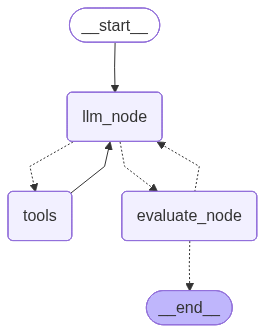

Graph compiled.


In [7]:
################################################################################
# Cell 5 — LangGraph Pipeline
#
# Note: langgraph.prebuilt (ToolNode) is not available in this version of langgraph.
# A minimal custom ToolNode is implemented below that is functionally equivalent.
################################################################################

import dotenv, os, json
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage
from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_anthropic import ChatAnthropic
from langgraph.graph import MessagesState, StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import Image, display

dotenv.load_dotenv(os.getcwd() + '/../.env')


class State(MessagesState):
    i: int
    max_f1s: float
    best_tool_calls: list


llm = ChatOpenAI(model='gpt-4o', temperature=0.1)
# llm = ChatGoogleGenerativeAI(model='gemini-1.5-pro', temperature=0.1)
# llm = ChatAnthropic(model='claude-haiku-4-5-20251001', temperature=0.1)

tools_list = [evaluation_tool]
llm_with_tools = llm.bind_tools(tools_list)


def extract_tool_calls(message):
    """Return normalized tool calls from either parsed or raw OpenAI format."""
    parsed = getattr(message, 'tool_calls', None)
    if parsed:
        return parsed
    raw_calls = (getattr(message, 'additional_kwargs', {}) or {}).get('tool_calls', [])
    normalized = []
    for call in raw_calls:
        fn = call.get('function', {})
        args = fn.get('arguments', {})
        if isinstance(args, str):
            try:
                args = json.loads(args)
            except Exception:
                args = {}
        normalized.append({'id': call.get('id', ''), 'name': fn.get('name', ''), 'args': args})
    return normalized


# Custom ToolNode — replaces langgraph.prebuilt.ToolNode (unavailable in this version)
def make_tool_node(tools):
    tools_by_name = {t.name: t for t in tools}
    def tool_node(state):
        ai_msg = next(
            m for m in reversed(state['messages'])
            if extract_tool_calls(m)
        )
        results = []
        for tc in extract_tool_calls(ai_msg):
            result = tools_by_name[tc['name']].invoke(tc['args'])
            results.append(ToolMessage(content=str(result), tool_call_id=tc['id']))
        return {'messages': results}
    return tool_node


def llm_node(state):
    completion = llm_with_tools.invoke(state['messages'])
    return {'messages': [completion], 'i': state['i'] + 1}


def evaluate_node(state):
    """Evaluate current rules on known-attack test set and send feedback to LLM."""
    ai_messages = [
        m for m in state['messages']
        if isinstance(m, AIMessage) and extract_tool_calls(m)
    ]
    if not ai_messages:
        return {}
    tool_calls = extract_tool_calls(ai_messages[-1])

    datasets = {'normal': normal_df_test, 'attack': attack_df_test}
    y_pred, y_true = [], []
    for label, dataset in datasets.items():
        for i in tqdm(range(len(dataset)), disable=False, ncols=100,
                      desc=f'Test eval {label}...'):
            try:
                votes = [
                    'attack' if operators[tc['args']['op']](
                        dataset.iloc[i][tc['args']['feature_name']],
                        float(tc['args']['value'])
                    ) else 'normal'
                    for tc in tool_calls
                ]
                y_pred.append(mode(votes))
            except Exception:
                y_pred.append('normal')
            y_true.append(label)

    report = classification_report(y_true, y_pred, digits=4, output_dict=True)
    matrix = confusion_matrix(y_true, y_pred)
    f1     = report['macro avg']['f1-score']
    print(f'  Iter {state["i"]}: known-attack test macro-F1 = {f1:.4f}')
    print(matrix)

    new_max  = max(state['max_f1s'], f1)
    new_best = tool_calls if f1 >= state['max_f1s'] else state['best_tool_calls']

    feedback = HumanMessage(
        f'Current macro avg F1 on test set (known attacks only): {f1:.4f}. '
        f'Best so far: {new_max:.4f}. '
        f'If this is greater than the previous best, keep performing rules and revise underperforming ones. '
        f'Otherwise revise all rules to exceed the best. '
        f'Generate exactly {k} rules and make a tool call for each.'
    )
    return {
        'messages': [feedback],
        'max_f1s':  new_max,
        'best_tool_calls': new_best,
    }


def tools_condition_edge(state):
    return 'tools' if extract_tool_calls(state['messages'][-1]) else 'evaluate_node'


def feedback_condition_edge(state):
    return 'llm_node' if state['i'] < n else END


builder = StateGraph(State)
builder.add_node('llm_node', llm_node)
builder.add_node('tools', make_tool_node(tools_list))
builder.add_node('evaluate_node', evaluate_node)

builder.add_edge(START, 'llm_node')
builder.add_conditional_edges('llm_node', tools_condition_edge, ['tools', 'evaluate_node'])
builder.add_edge('tools', 'llm_node')
builder.add_conditional_edges('evaluate_node', feedback_condition_edge, ['llm_node', END])

graph = builder.compile(checkpointer=MemorySaver())
display(Image(graph.get_graph().draw_mermaid_png()))
print('Graph compiled.')

In [8]:
################################################################################
# Cell 6 — Run pipeline (primary seed)
################################################################################

system_message = SystemMessage(
    f"""You are a skilled security data analyst.
You are provided with network data entries categorized as either normal or attack, along with their corresponding feature names.
Carefully analyze the differences between normal and attack entries by comparing corresponding fields.
Your task is to generate exactly {k} simple and deterministic rules for the top {k} important features to filter attack entries.
Supported operators: >, <, >=, <=
NEVER use '==' or '!=' - these are forbidden for numeric features.
Generate exactly {k} rules and make a tool call for each rule."""
)

human_message = HumanMessage(
    f"""Analyze the following network data and generate {k} rules to identify attack entries.

Normal Entries:
```{normal_entries}```

Attack Entries:
```{attack_entries}```"""
)

initial_state = State(
    i=0,
    max_f1s=0.5,
    best_tool_calls=[],
    messages=[system_message, human_message]
)
config = {
    'configurable': {'thread_id': f'zd-{DATASET_NAME}-{WITHHELD_CLASS}-seed{SEED_MAIN}'},
    'recursion_limit': 100
}

print(f'Running pipeline')
print(f'  Dataset        : {DATASET_NAME}')
print(f'  Withheld class : {WITHHELD_CLASS}')
print(f'  Seed           : {SEED_MAIN}')
print(f'  Training       : {len(normal_df_train):,} normal + {len(attack_df_train):,} known-attack')
print(f'  Zero-day test  : {len(zeroday_df_test):,} samples of "{WITHHELD_CLASS}"\n')

output = graph.invoke(initial_state, config)

best_tool_calls = output['best_tool_calls']
best_f1 = output['max_f1s']

print(f'\nBest known-attack macro-F1 : {best_f1:.4f}')
print(f'Rules ({len(best_tool_calls)}):')
for tc in best_tool_calls:
    a = tc['args']
    print(f'  {a["feature_name"]:25s} {a["op"]:2s} {a["value"]}')

Running pipeline
  Dataset        : bot-iot
  Withheld class : Service_Scan
  Seed           : 42
  Training       : 296 normal + 296 known-attack
  Zero-day test  : 58,626 samples of "Service_Scan"



Test eval attack...: 100%|████████████████████████████████████████| 74/74 [00:00<00:00, 8504.69it/s]


  Iter 2: known-attack test macro-F1 = 0.9662
[[74  0]
 [ 5 69]]


Test eval attack...: 100%|████████████████████████████████████████| 74/74 [00:00<00:00, 8617.56it/s]


  Iter 4: known-attack test macro-F1 = 0.9594
[[74  0]
 [ 6 68]]


Test eval attack...: 100%|████████████████████████████████████████| 74/74 [00:00<00:00, 3963.61it/s]

  Iter 6: known-attack test macro-F1 = 0.9046
[[74  0]
 [14 60]]

Best known-attack macro-F1 : 0.9662
Rules (5):
  seq                       >  23876
  stddev                    >  0.231947
  N_IN_Conn_P_SrcIP         >  26
  N_IN_Conn_P_DstIP         >  10
  srate                     <  0.399824


In [9]:
################################################################################
# Cell 7 — Standard binary evaluation on known attacks (sanity check)
################################################################################


def apply_rules_binary(tool_calls, normal_df, attack_df):
    """Majority-vote rule application. Returns (report_dict, confusion_matrix)."""
    y_pred, y_true = [], []
    for label, dataset in [('normal', normal_df), ('attack', attack_df)]:
        for i in tqdm(range(len(dataset)), disable=False, ncols=100, desc=f'Eval {label}...'):
            try:
                votes = [
                    'attack' if operators[tc['args']['op']](
                        dataset.iloc[i][tc['args']['feature_name']], float(tc['args']['value'])
                    ) else 'normal'
                    for tc in tool_calls
                ]
                y_pred.append(mode(votes))
            except Exception:
                y_pred.append('normal')
            y_true.append(label)
    return (
        classification_report(y_true, y_pred, digits=4, output_dict=True),
        confusion_matrix(y_true, y_pred, labels=['normal', 'attack'])
    )


print('=== Standard Binary Evaluation (known attacks only — sanity check) ===')
known_report, known_matrix = apply_rules_binary(
    best_tool_calls, normal_df_test, attack_df_test
)
print(f'Macro F1  : {known_report["macro avg"]["f1-score"]:.4f}')
print(f'Precision : {known_report["macro avg"]["precision"]:.4f}')
print(f'Recall    : {known_report["macro avg"]["recall"]:.4f}')
print(f'\nConfusion matrix (rows=true, cols=pred, order=[normal, attack]):')
print(known_matrix)

=== Standard Binary Evaluation (known attacks only — sanity check) ===


Eval attack...: 100%|█████████████████████████████████████████████| 74/74 [00:00<00:00, 8975.15it/s]

Macro F1  : 0.9662
Precision : 0.9684
Recall    : 0.9662

Confusion matrix (rows=true, cols=pred, order=[normal, attack]):
[[69  5]
 [ 0 74]]


In [10]:
################################################################################
# Cell 8 — Zero-day evaluation
################################################################################


def evaluate_zero_day(tool_calls, zd_df: pd.DataFrame):
    """
    Apply rules to the withheld class.
    Returns (ZDR, predictions_list).
    ZDR = fraction of withheld entries flagged as 'attack'.
    """
    preds = []
    for i in tqdm(range(len(zd_df)), ncols=100,
                  desc=f'Zero-day eval [{WITHHELD_CLASS}]...'):
        try:
            votes = [
                'attack' if operators[tc['args']['op']](
                    zd_df.iloc[i][tc['args']['feature_name']], float(tc['args']['value'])
                ) else 'normal'
                for tc in tool_calls
            ]
            preds.append(mode(votes))
        except Exception:
            preds.append('normal')
    zdr = sum(p == 'attack' for p in preds) / max(len(preds), 1)
    return zdr, preds


llm_zdr, llm_preds = evaluate_zero_day(best_tool_calls, zeroday_df_test)

detected = sum(p == 'attack' for p in llm_preds)
missed   = sum(p == 'normal' for p in llm_preds)

print(f'\n=== Zero-Day Evaluation: "{WITHHELD_CLASS}" ===')
print(f'Total zero-day samples : {len(zeroday_df_test):,}')
print(f'Detected as attack     : {detected:,}')
print(f'Missed (as normal)     : {missed:,}')
print(f'\nZero-Day Detection Rate (ZDR): {llm_zdr:.4f}  ({llm_zdr*100:.1f}%)')
zdr_label = 'Strong' if llm_zdr > 0.8 else ('Moderate' if llm_zdr > 0.5 else 'Weak')
print(f'Generalisation strength      : {zdr_label}')
print(f'\nInterpretation:')
print(f'  ZDR > 80%: Rules capture abstract attack indicators beyond training profiles')
print(f'  ZDR 50-80%: Partial generalisation')
print(f'  ZDR < 50%: Rules specific to seen attack profiles, fail on zero-day')

Zero-day eval [Service_Scan]...: 100%|██████████████████████| 58626/58626 [00:09<00:00, 6189.76it/s]


=== Zero-Day Evaluation: "Service_Scan" ===
Total zero-day samples : 58,626
Detected as attack     : 38,049
Missed (as normal)     : 20,577

Zero-Day Detection Rate (ZDR): 0.6490  (64.9%)
Generalisation strength      : Moderate

Interpretation:
  ZDR > 80%: Rules capture abstract attack indicators beyond training profiles
  ZDR 50-80%: Partial generalisation
  ZDR < 50%: Rules specific to seen attack profiles, fail on zero-day


In [11]:
################################################################################
# Cell 9 — ML baseline comparison under same zero-day condition
################################################################################

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

X_train = train_df[feature_cols].values
y_train = train_df['binary_label'].values
X_test  = test_known_df[feature_cols].values
y_test  = test_known_df['binary_label'].values
X_zd    = zeroday_df_test.values

results_summary = []
dt_model, rf_model = None, None

for name, model in [
    ('Decision Tree', DecisionTreeClassifier(random_state=SEED_MAIN)),
    ('Random Forest', RandomForestClassifier(n_estimators=100, random_state=SEED_MAIN, n_jobs=-1)),
]:
    model.fit(X_train, y_train)
    if name == 'Decision Tree': dt_model = model
    if name == 'Random Forest': rf_model = model

    y_pred_test = model.predict(X_test)
    rep         = classification_report(y_test, y_pred_test, output_dict=True)
    known_f1    = rep['macro avg']['f1-score']

    y_pred_zd = model.predict(X_zd)
    ml_zdr    = (y_pred_zd == 'attack').mean()

    results_summary.append([name, f'{known_f1:.4f}', f'{ml_zdr:.4f}  ({ml_zdr*100:.1f}%)'])
    print(f'{name:20s}  known-F1 = {known_f1:.4f}  |  ZDR = {ml_zdr:.4f}')

# Add LLM result at top
results_summary.insert(0, [
    'LLM-generated rules',
    f'{known_report["macro avg"]["f1-score"]:.4f}',
    f'{llm_zdr:.4f}  ({llm_zdr*100:.1f}%)'
])

Decision Tree         known-F1 = 1.0000  |  ZDR = 0.8747
Random Forest         known-F1 = 1.0000  |  ZDR = 0.8617


In [12]:
################################################################################
# Cell 10 — Results summary table + save to disk
################################################################################

import json, datetime

print(f'\n=== ZERO-DAY EXPERIMENT RESULTS ===')
print(f'Dataset  : Bot-IoT')
print(f'Withheld : {WITHHELD_CLASS}  ({len(zeroday_df_test):,} zero-day test samples)')
print(f'Seed     : {SEED_MAIN}')
print()
print(tabulate(
    results_summary,
    headers=['Method', 'Known-Attack F1', f'ZDR — {WITHHELD_CLASS}'],
    tablefmt='grid'
))

os.makedirs('results/llm', exist_ok=True)
ts = datetime.datetime.now().strftime('%Y-%m-%d-%H-%M-%S')
out = {
    'dataset': DATASET_NAME,
    'withheld_class': WITHHELD_CLASS,
    'seed': SEED_MAIN,
    'zero_day_samples': len(zeroday_df_test),
    'known_f1_llm': known_report['macro avg']['f1-score'],
    'zdr_llm': llm_zdr,
    'rules': [tc['args'] for tc in best_tool_calls],
}
with open(f'results/llm/zeroday-{WITHHELD_CLASS}-seed{SEED_MAIN}-{ts}.json', 'w') as f:
    json.dump(out, f, indent=2)
print(f'\nResults saved to results/llm/zeroday-{WITHHELD_CLASS}-seed{SEED_MAIN}-{ts}.json')


=== ZERO-DAY EXPERIMENT RESULTS ===
Dataset  : Bot-IoT
Withheld : Service_Scan  (58,626 zero-day test samples)
Seed     : 42

+---------------------+-------------------+----------------------+
| Method              |   Known-Attack F1 | ZDR — Service_Scan   |
+=====================+===================+======================+
| LLM-generated rules |            0.9662 | 0.6490  (64.9%)      |
+---------------------+-------------------+----------------------+
| Decision Tree       |            1      | 0.8747  (87.5%)      |
+---------------------+-------------------+----------------------+
| Random Forest       |            1      | 0.8617  (86.2%)      |
+---------------------+-------------------+----------------------+

Results saved to results/llm/zeroday-Service_Scan-seed42-2026-04-20-12-26-42.json


In [14]:
################################################################################
# Cell 11 — Multi-seed runs for error bars
################################################################################

seed_results = []

for s in SEEDS:
    print(f'\n--- Seed {s} ---')

    n_repr_s = get_representative_samples_bge(normal_df_train, n=N_REPR, max_embed=MAX_EMBED, seed=s)
    a_repr_s = get_representative_samples_bge(attack_df_train, n=N_REPR, max_embed=MAX_EMBED, seed=s)
    n_entries = json.dumps({col: n_repr_s[col].tolist() for col in feature_cols})
    a_entries = json.dumps({col: a_repr_s[col].tolist() for col in feature_cols})

    g = builder.compile(checkpointer=MemorySaver())
    state_s = State(
        i=0, max_f1s=0.5, best_tool_calls=[],
        messages=[
            SystemMessage(system_message.content),
            HumanMessage(
                f'Analyze the following network data and generate {k} rules to identify attack entries.\n\n'
                f'Normal Entries:\n```{n_entries}```\n\n'
                f'Attack Entries:\n```{a_entries}```'
            )
        ]
    )
    cfg_s = {
        'configurable': {'thread_id': f'zd-{DATASET_NAME}-{WITHHELD_CLASS}-seed{s}'},
        'recursion_limit': 100
    }
    out_s = g.invoke(state_s, cfg_s)

    best_s = out_s['best_tool_calls']
    zdr_s, _ = evaluate_zero_day(best_s, zeroday_df_test)
    known_s_report, _ = apply_rules_binary(best_s, normal_df_test, attack_df_test)
    seed_results.append({
        'seed': s,
        'known_f1': known_s_report['macro avg']['f1-score'],
        'zdr': zdr_s
    })
    print(f'  Known-F1: {known_s_report["macro avg"]["f1-score"]:.4f}  |  ZDR: {zdr_s:.4f}')

zdr_vals   = [r['zdr']      for r in seed_results]
known_vals = [r['known_f1'] for r in seed_results]
print(f'\n=== Multi-seed summary (n={len(SEEDS)}) ===')
print(f'Known-attack F1 : {np.mean(known_vals):.4f} ± {np.std(known_vals):.4f}')
print(f'ZDR             : {np.mean(zdr_vals):.4f} ± {np.std(zdr_vals):.4f}')


--- Seed 42 ---


Test eval attack...: 100%|████████████████████████████████████████| 74/74 [00:00<00:00, 7786.91it/s]


  Iter 2: known-attack test macro-F1 = 0.9662
[[74  0]
 [ 5 69]]


Test eval attack...: 100%|████████████████████████████████████████| 74/74 [00:00<00:00, 7613.29it/s]


  Iter 6: known-attack test macro-F1 = 0.8113
[[74  0]
 [27 47]]


...

  Iter 4: known-attack test macro-F1 = 0.8335
[[50 24]
 [ 0 74]]


/Users/S4160163/Documents/Projects/RAG Paper/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/S4160163/Documents/Projects/RAG Paper/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/S4160163/Documents/Projects/RAG Paper/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

  Iter 6: known-attack test macro-F1 = 0.5892
[[21 53]
 [ 0 74]]


Eval attack...: 100%|█████████████████████████████████████████████| 74/74 [00:00<00:00, 4041.76it/s]

  Known-F1: 0.9865  |  ZDR: 0.2086

=== Multi-seed summary (n=3) ===
Known-attack F1 : 0.9752 ± 0.0084
ZDR             : 0.2878 ± 0.2685


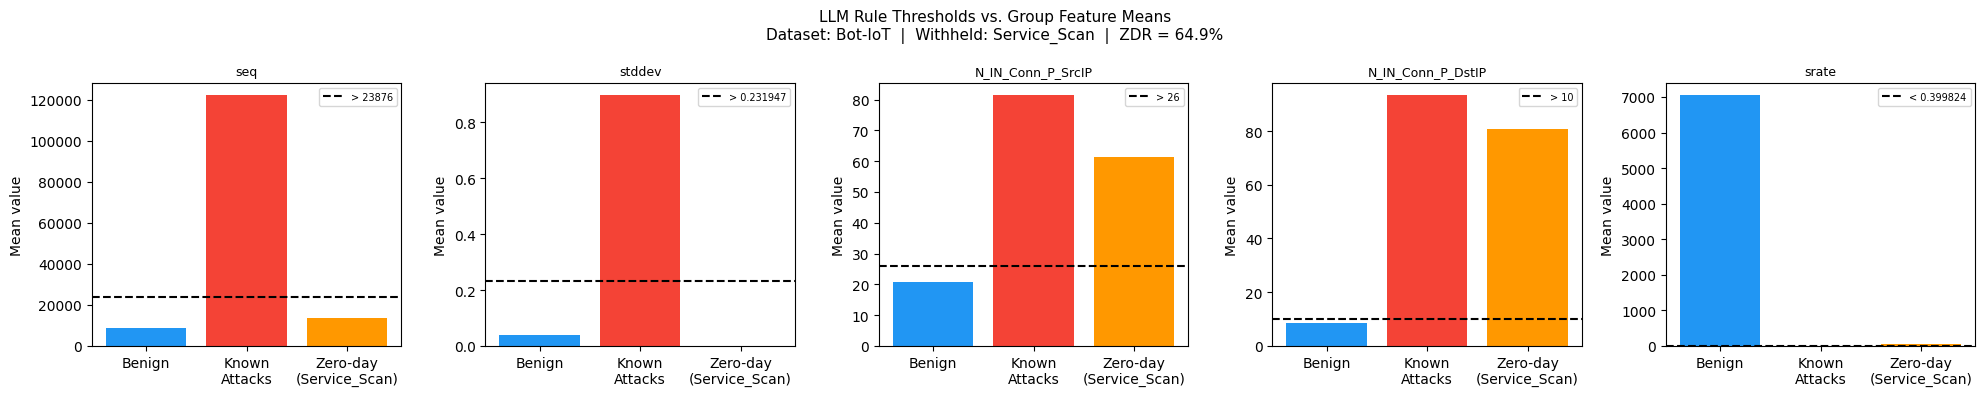

Figure saved.


In [13]:
################################################################################
# Cell 12 — Visualise: rule thresholds vs mean feature values per group
################################################################################

import matplotlib.pyplot as plt

rule_features = [tc['args']['feature_name'] for tc in best_tool_calls]
rule_ops      = [tc['args']['op']           for tc in best_tool_calls]
rule_values   = [tc['args']['value']        for tc in best_tool_calls]

benign_means = normal_df_train[rule_features].mean()
known_means  = attack_df_train[rule_features].mean()
zd_means     = zeroday_df_test[rule_features].mean()

n_rules = len(rule_features)
fig, axes = plt.subplots(1, n_rules, figsize=(4 * n_rules, 4))
if n_rules == 1:
    axes = [axes]

for ax, feat, op_str, thresh in zip(axes, rule_features, rule_ops, rule_values):
    ax.bar(
        ['Benign', 'Known\nAttacks', f'Zero-day\n({WITHHELD_CLASS[:14]})'],
        [benign_means[feat], known_means[feat], zd_means[feat]],
        color=['#2196F3', '#F44336', '#FF9800']
    )
    ax.axhline(y=float(thresh), color='black', linestyle='--', linewidth=1.5,
               label=f'{op_str} {thresh}')
    ax.set_title(feat, fontsize=9)
    ax.set_ylabel('Mean value')
    ax.legend(fontsize=7, loc='upper right')

fig.suptitle(
    f'LLM Rule Thresholds vs. Group Feature Means\n'
    f'Dataset: Bot-IoT  |  Withheld: {WITHHELD_CLASS}  |  ZDR = {llm_zdr*100:.1f}%',
    fontsize=11
)
plt.tight_layout()
os.makedirs('results', exist_ok=True)
plt.savefig(f'results/zeroday-{WITHHELD_CLASS}-thresholds.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')